In [1]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore',category=FutureWarning)

In [5]:
import pandas as pd
amazon=pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Reviews.csv', engine='python', on_bad_lines='skip')

In [6]:
amazon.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [8]:
amazon.shape

(568454, 10)

In [9]:
amazon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [10]:
for index,row in amazon.iterrows():
  hn=row['HelpfulnessNumerator']
  hd=row['HelpfulnessDenominator']

  if hn>hd:
    print(f"error in row {index}: HelpfulnessNumertaor({hn}) is greater than HelpfulnessDenominator({hd})")

error in row 44736: HelpfulnessNumertaor(3) is greater than HelpfulnessDenominator(2)
error in row 64421: HelpfulnessNumertaor(3) is greater than HelpfulnessDenominator(1)


In [11]:
amazon=amazon[amazon['HelpfulnessNumerator']<=amazon['HelpfulnessDenominator']]

In [12]:
amazon.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
568449,False
568450,False
568451,False
568452,False


In [13]:
if amazon.duplicated(['UserId','ProfileName','Time','Text']).any():
  print(f"tehre re as many as {amazon.duplicated(['UserId','ProfileName','Time','Text']).sum()}")
else:
  print("no duplicated")

tehre re as many as 174521


In [14]:
amazon=amazon.drop_duplicates(subset=['UserId','ProfileName','Text','Time'])

In [15]:
if amazon.duplicated(['UserId','ProfileName','Time','Text']).any():
  print(f"tehre re as many as {amazon.duplicated(['UserId','ProfileName','Time','Text']).sum()}")
else:
  print("no duplicated")

no duplicated


In [16]:
amazon.shape

(393931, 10)

In [17]:
missing=amazon.isnull().sum()
missing=missing[missing>0]
if not missing.empty:
  print("columns with missing are")
  for column,count in missing.items():
    print(f"{column}:{count} missing")
else:
  print("no missing")

columns with missing are
ProfileName:16 missing
Summary:3 missing


In [18]:
amazon['Time']=pd.to_datetime(amazon['Time'],unit='s')
amazon['Time'].head()

,Time
0,2011-04-27
1,2012-09-07
2,2008-08-18
3,2011-06-13
4,2012-10-21


In [19]:
amazon['UserId'].nunique()

256059

In [21]:
recc=amazon.groupby(['UserId']).agg({'Summary':'count','Text':'count','Score':'count','ProductId':'count'}).sort_values(by="ProductId",ascending=False)

In [22]:
recc.head()

,Summary,Text,Score,ProductId
UserId,,,,
AY12DBB0U420B,329,329,329,329
A3OXHLG6DIBRW8,278,278,278,278
A281NPSIMI1C2R,259,259,259,259
A1YUL9PCJR3JTY,214,214,214,214
A1Z54EM24Y40LL,211,211,211,211


In [23]:
top_10=recc.index[0:10]
purchase=recc['ProductId'][0:10].values

Text(0, 0.5, 'userid')

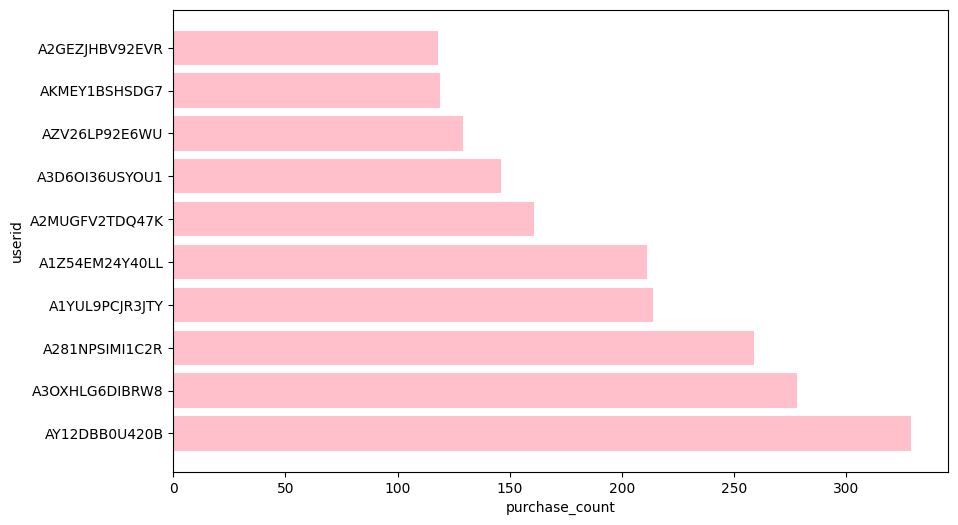

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.barh(top_10,purchase,color='pink')
plt.xlabel('purchase_count')
plt.ylabel('userid')
#something with enumerate